In [1]:
%load_ext autoreload
%autoreload 2

### Set up the dataset

In [23]:
from utils import save_sketches, setup_dataset, generate_sketch_pairs

setup_dataset(download_limit=3, category="chair")
save_sketches(num_views=6, category="chair")

Fetching Objaverse LVIS annotations...

Copying files to local directory: ./dataloader/data/chair/meshes/
Saved: dataloader/data/chair/meshes/304253851afd493d958fc8e256c189df.glb
Saved: dataloader/data/chair/meshes/8a4a3a90bc104f11b82cedd9b4e5ab6b.glb
Saved: dataloader/data/chair/meshes/fab9443d48e24fbfa309187df78d58e6.glb
Found 3 meshes. Starting batch generation...
[1/3] Processing: 304253851afd493d958fc8e256c189df
Loading and normalizing: 304253851afd493d958fc8e256c189df.glb
[2/3] Processing: 8a4a3a90bc104f11b82cedd9b4e5ab6b
Loading and normalizing: 8a4a3a90bc104f11b82cedd9b4e5ab6b.glb
[3/3] Processing: fab9443d48e24fbfa309187df78d58e6
Loading and normalizing: fab9443d48e24fbfa309187df78d58e6.glb

Batch processing complete! Check your 'images' and 'sketches' folders.


### Preview renderings

Found 6 images to preview.


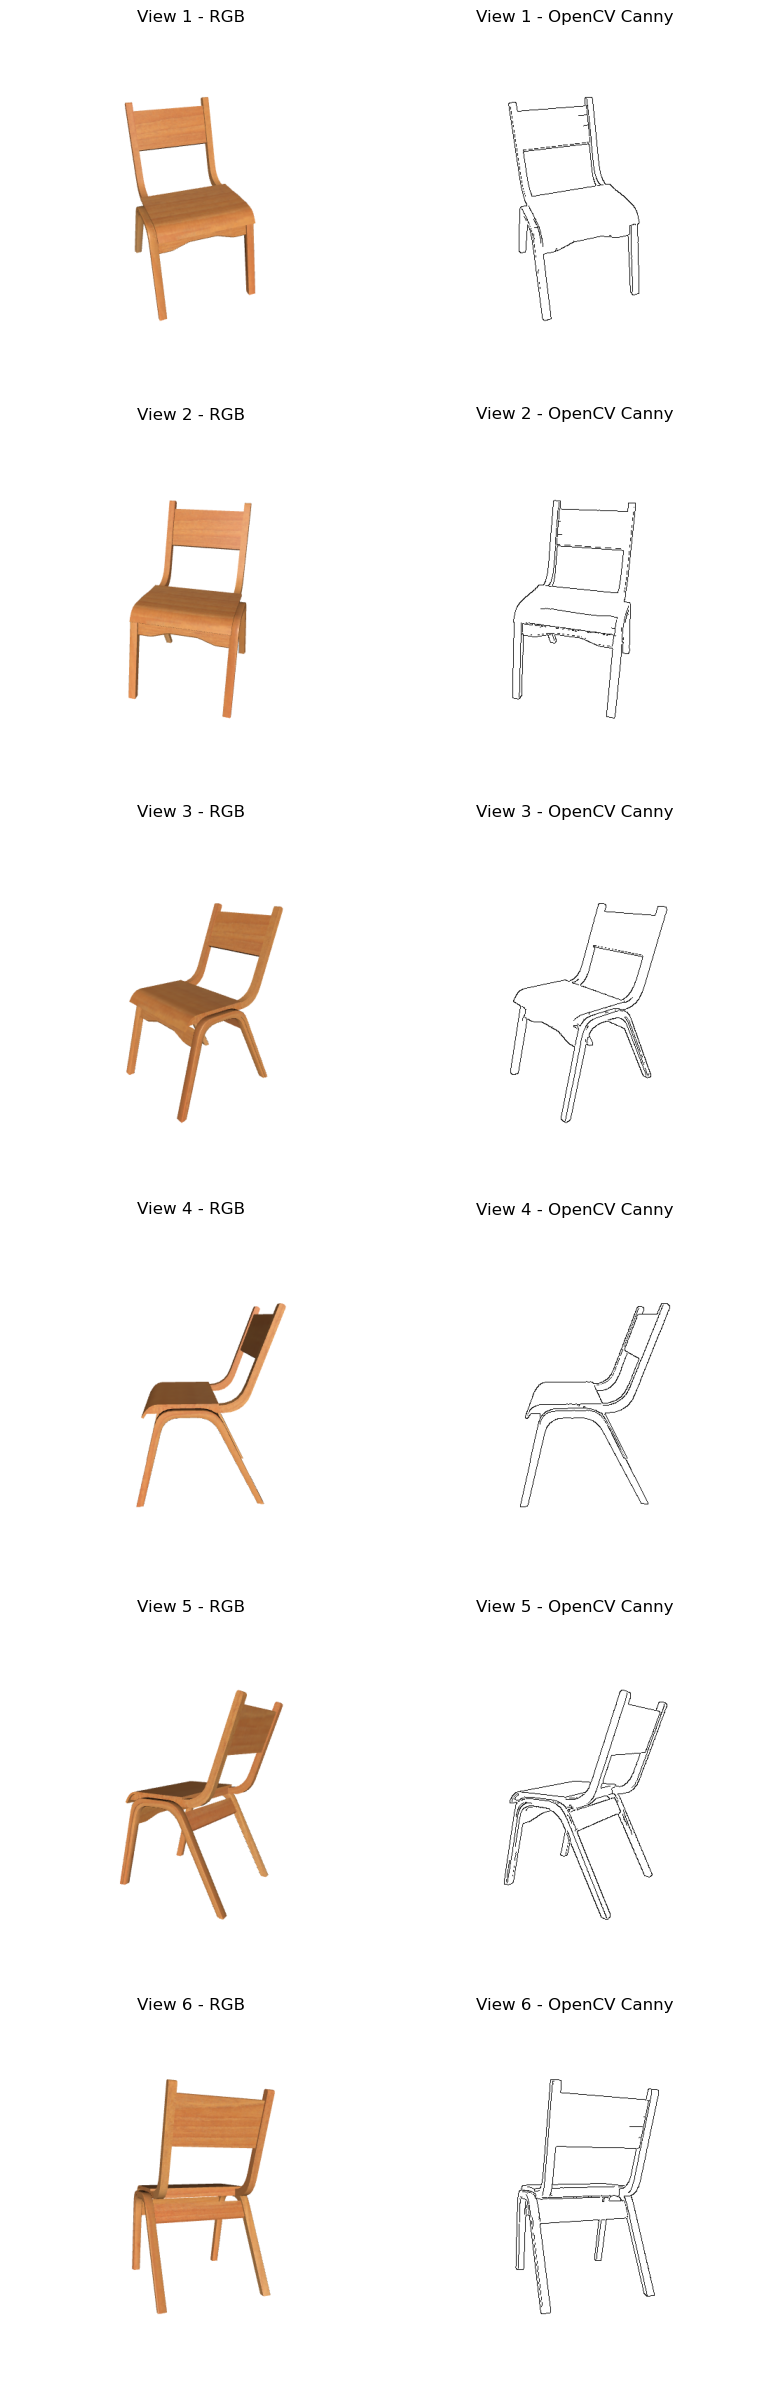

In [24]:
import os
import glob
import cv2
import matplotlib.pyplot as plt

# 1. Define your dataset directories
img_dir = "data/chair/images"
sketch_dir = "data/chair/sketches"

# 2. Grab the first 3 image paths
# Using sorted() ensures we get them in order (e.g., view0, view1, view2 of the same chair)
image_paths = sorted(glob.glob(os.path.join(img_dir, "*.png")))[:6]
total_views = len(image_paths)

print(f"Found {total_views} images to preview.")

# 3. Setup the dynamic plot
fig, axes = plt.subplots(total_views, 2, figsize=(8, 4 * total_views))

# Handle the edge case where there is only 1 image (axes wouldn't be a 2D array)
if total_views == 1:
    axes = [axes]

for i, img_path in enumerate(image_paths):
    # Extract just the filename (e.g., '8a4a3a90_view0.png')
    filename = os.path.basename(img_path)
    
    # Construct the path to the matching sketch
    sketch_path = os.path.join(sketch_dir, filename)
    
    # --- LOAD IMAGES ---
    # OpenCV loads images in BGR format, so we must convert to RGB for Matplotlib
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Load the sketch in grayscale mode
    sketch = cv2.imread(sketch_path, cv2.IMREAD_GRAYSCALE)
    
    # --- PLOT RGB ---
    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f"View {i + 1} - RGB")
    axes[i, 0].axis('off')
    
    # --- PLOT SKETCH ---
    axes[i, 1].imshow(sketch, cmap='gray')
    axes[i, 1].set_title(f"View {i + 1} - OpenCV Canny")
    axes[i, 1].axis('off')
    
plt.tight_layout()
plt.show()

### Check the DataLoader

In [ ]:
from utils import sparse_collate_fn
from dataset import SketchMeshDataset
from torch.utils.data import DataLoader

# 1. Initialize the Dataset
dataset = SketchMeshDataset(root_dir="data", category="chair", image_size=512, split="test")

# 2. Initialize the DataLoader
dataloader = DataLoader(
    dataset, 
    batch_size=10,        # How many images to process at once
    shuffle=False,        # Randomize the order (crucial for training)
    num_workers=2,       # Multi-processing for faster data loading
    collate_fn=sparse_collate_fn,
    drop_last=True       # Drops the last incomplete batch if dataset size isn't divisible by 8
)

# 3. Test the DataLoader loop
seen_uids = set()

for batch_idx, batch in enumerate(dataloader):
    print(f"Batch {batch_idx + 1}")
    uids = batch["uid"]
    view_ids = batch["view_id"]


    # --------------------------------------------------
    # 1. SHAPE CHECKS
    # --------------------------------------------------
    print(f" - Images shape:  {batch['image'].shape}")   # Expected: [8, 3, 512, 512]
    print(f" - Sketches shape:{batch['sketch'].shape}")  # Expected: [8, 3, 512, 512]
    print(f" - latent_feats shape:{batch['latent_feats'].shape}")  # Expected: [big_number, 8]
    print(f" - latent_coords shape:{batch['latent_coords'].shape}")  # Expected: [big_number, 4]
    print(f" - ss_latents shape:{batch['ss_latent'].shape}")  # Expected: [big_number, 4]

    print(f" - cond_tokens shape:{batch['cond_tokens'].shape}")  # Expected: [big_number, 4]
    print(f" - neg_cond_tokens shape:{batch['neg_cond_tokens'].shape}")  # Expected: [big_number, 4]

    print(f" - mesh_paths in batch: {batch['mesh_path']}")
    print(f" - image_paths in batch: {batch['image_path']}")
    print(f" - sketch_paths in batch: {batch['sketch_path']}")

    # --------------------------------------------------
    # 2. UID CONSISTENCY CHECK (VERY IMPORTANT)
    # --------------------------------------------------
    unique_uids = set(uids)

    print("UIDs in batch:", unique_uids)

    if len(unique_uids) > 1:
        print("WARNING: mixed UIDs in same batch!")

    # --------------------------------------------------
    # 3. VIEW DIVERSITY CHECK
    # --------------------------------------------------
    print("View IDs:", view_ids)

    # check duplicates
    if len(set(view_ids)) < len(view_ids):
        print("⚠ WARNING: duplicate view_ids in batch!")

    # --------------------------------------------------
    # 4. SPLIT LEAKAGE CHECK (optional but powerful)
    # --------------------------------------------------
    for uid, v in zip(uids, view_ids):
        key = f"{uid}_{v}"
        if key in seen_uids:
            print("WARNING: duplicate sample seen:", key)
        seen_uids.add(key)

    # --------------------------------------------------
    # 5. LATENT SANITY CHECK (VERY IMPORTANT FOR TRELLIS)
    # --------------------------------------------------
    feats = batch["latent_feats"]

    print("latent_feats mean/std:",
          feats.mean().item(),
          feats.std().item())

    ss = batch["ss_latent"]
    print("ss_latent mean/std:",
          ss.mean().item(),
          ss.std().item())

    # break # Just run one batch to verify

Loaded 60 valid data pairs for category 'chair'.
Batch 1
 - Images shape:  torch.Size([10, 3, 512, 512])
 - Sketches shape:torch.Size([10, 3, 512, 512])
 - latent_feats shape:torch.Size([81751, 8])
 - latent_coords shape:torch.Size([81751, 4])
 - ss_latents shape:torch.Size([10, 8, 16, 16, 16])
 - cond_tokens shape:torch.Size([10, 1374, 1024])
 - neg_cond_tokens shape:torch.Size([10, 1374, 1024])
 - mesh_paths in batch: ['data\\chair\\meshes\\0494222eb1cd46749fe9931dd6c4c30f.glb', 'data\\chair\\meshes\\053039b95c314104b5fe0dfb19f43cb3.glb', 'data\\chair\\meshes\\09fd6b85dfc84ccfac7b6d3ef378fea2.glb', 'data\\chair\\meshes\\19b2c1893f084653ab226cc3faf27c96.glb', 'data\\chair\\meshes\\1d3687a764404fc9a2ff78a06b873ecd.glb', 'data\\chair\\meshes\\1d7a66437c954638b69bbeefa774c4b2.glb', 'data\\chair\\meshes\\1dae31a7fa54440688eebaa0376c56d3.glb', 'data\\chair\\meshes\\2353c11119674786955adfda7368df62.glb', 'data\\chair\\meshes\\2820827abdcd4e79b7c67683292416aa.glb', 'data\\chair\\meshes\\2972